# Rectified Image Processing for Thermal Landscapes Project
 PB 6/6/2022
 
Reads in rectified multiband thermal images from each site and looks for images that overlap with shapefiles of inside/outside the exclosures. Extracts metrics from thermal images for analysis.

In [1]:
import rasterio as rio
import numpy as np
import geopandas as gpd
from pathlib import Path
import xarray as xr
import rioxarray as rioxr
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
import pandas as pd
import warnings

# makes matplotlib plots big
plt.rcParams['figure.figsize'] = [12, 9]
plt.rcParams.update({'font.size': 11})

# Define inputs
img_dir = Path('/n/davies_lab/Lab/data/products/2020_01-02/MakhEP/raster/thermal/rectifiedimages')
shp_f = Path('./data/in/MakhEP_ExclosurePolygon_AD/Makhohlola_polygon.shp')

# Load shapefile
shp = gpd.read_file(shp_f)

In [3]:
# Rasterize Shapefile for zonal stats
# TBD

In [4]:
# Note: This method works, but it's not super efficient, since it's rasterizing the shapefile every iteration
# If you rasterize the shapefile first into an xarray raster object using geocube
# then clip/compute stats, that should be more efficient 6/10/22
# See: https://corteva.github.io/geocube/html/examples/zonal_statistics.html

# dict of filenames, their bounding polygons, and their pixel xarrays 
# nested in a dict with the shapefile ids as keys
pixel_dict = {'imgf':[], 'boundary_poly':[], 'overlapperc':[],
              'pixels_xr':{1:[], 2:[]}, 'N':{1:[], 2:[]}}

# Make list of images to loop through
imglist = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# imglist = imglist[0:10]

# Shuffle the images so you start on a different on each time
np.random.shuffle(imglist)

# Set threshold of overlap tolerance
threshold = 0.10

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# doesn't work for everything...
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Loop through each image
    for i, f in enumerate(imglist):

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # extract the temp band and convert to kelvin
        img_k = (img.sel(band=4)*0.04)

        # filter 0 degree C and below as nans
        img_k = img_k.where(img_k > 273.15)

        # fig, ax = plt.subplots()
        # img_k.plot(ax=ax, cmap='magma')
        # shp.plot(column='id', alpha=0.3, ax=ax, cmap='spring')
        # ax.set_title('')
        # ax.axis('equal')

        # Define polygon of bounds of img
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]

        polygon_geom = Polygon(zip(x_list, y_list))
        clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[polygon_geom])

        # Check the image's overlap with all previous images that have been processed thusfar
        # NOTE: you need to tell gpd to intersect with the shapely polygon (.geometry.values[0]) NOT the gdf of clipbox!
        # Otherwise, it only runs the intersection on the first row. 
        # Kind of dumb, but hey there it is.
        poly_gs = gpd.GeoSeries(data=pixel_dict['boundary_poly'], crs='EPSG:32736')
        poly_gs.intersects(clipbox.geometry.values[0])

        # Get the areas of the intersections
        poly_gs_intersect = poly_gs.intersection(clipbox.geometry.values[0])
        
        # Get the percentage overlap
        poly_overlapperc = poly_gs_intersect.area/clipbox.geometry.values[0].area
        
        # If any of these values are >= threshold %, don't run the file
        # But if there's minimal overlap, pass it on 
        overlap_idx = np.any(poly_overlapperc >= threshold)
        
        if not(overlap_idx):

            # If an img overlaps with BOTH shapefile features
            # See: https://geopandas.org/en/stable/docs/user_guide/missing_empty.html
            if np.any(clipbox.intersects(shp)):
                # if np.all(clipbox.intersection(shp).is_empty | clipbox.intersection(shp).isna()):

                # Save attributes in dict
                pixel_dict['imgf'].append(f)
                pixel_dict['overlapperc'].append(poly_overlapperc)
                # Save the shapely polygon (note: to get that you have to do .values[0])
                # See: https://github.com/geopandas/geopandas/issues/1353
                pixel_dict['boundary_poly'].append(clipbox.geometry.values[0])

                # loop through features in shapefile
                for ID, feature in zip(shp.id, shp.geometry):

                    # Get the intersection, and clip your raster with it
                    pixels = img_k.rio.clip(clipbox.intersection(feature), drop=True)

                    # Store it in the nested dictionary
                    pixel_dict['pixels_xr'][ID].append(pixels)

                    # Also store number of non-na pixels in each
                    n = np.sum(np.isnan(pixels.data.flatten()))
                    pixel_dict['N'][ID].append(n)

                # Print stats
                # print(f'{ID}: {np.nanmean(pixels.data.flatten())}, {n} pixels')

# TBD - You need to check the overlap between the images, 
# perhaps by looping through the polygon boundary files
# Only save pixel_xr for images that do not overlap (that cover new area)
# This is difficult since you need to iteratively check against all images that have been saved thus far
# 6/9/22

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

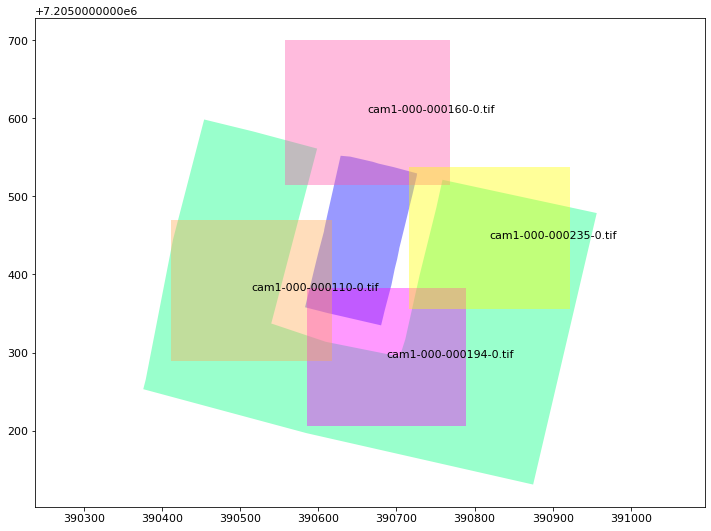

In [5]:
# Plot when done to get a sense of images and locations
fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4)
poly_gs.plot(ax=ax, alpha=0.4, cmap='spring')

labels = [str(s).split('/')[-1] for s in pixel_dict['imgf']]

for cx, cy, t in zip(poly_gs.centroid.x.values, poly_gs.centroid.y.values, labels):
    ax.text(cx, cy, t)

In [ ]:
#  playing with merging: https://docs.xarray.dev/en/stable/user-guide/combining.html
#inside_xr = xr.merge(pixel_dict['pixels_xr'][1], compat='override')
# inside_xr = pixel_dict['pixels_xr'][1][0].combine_first(pixel_dict['pixels_xr'][1][1])
# inside_xr = xr.combine_by_coords(pixel_dict['pixels_xr'][1])
# inside_xr.plot()
# fig.tight_layout()

In [137]:
# Testing overlap 
# poly_gs = gpd.GeoSeries(data=pixel_dict['boundary_poly'], crs='EPSG:32736')

# # NOTE: you need to tell gpd to intersect with the shapely polygon (.geometry.values[0]) NOT the gdf of clipbox!
# # Otherwise, it only runs the intersection on the first row. 
# # Kind of dumb, but hey there it is.
# poly_gs.intersects(clipbox.geometry.values[0])

# # Get the areas of the intersections
# poly_gs_intersect = poly_gs.intersection(clipbox.geometry.values[0])
# # Get the percentage overlap
# poly_overlapperc = poly_gs_intersect.area/clipbox.geometry.values[0].area
# # If any of these values are >= 10 %, don't run the file
# overlap_idx = np.any(poly_overlapperc >= 0.10)
# not(overlap_idx)

In [138]:
#  playing with merging: https://docs.xarray.dev/en/stable/user-guide/combining.html
#inside_xr = xr.merge(pixel_dict['pixels_xr'][1], compat='override')
# inside_xr = pixel_dict['pixels_xr'][1][0].combine_first(pixel_dict['pixels_xr'][1][1])
# inside_xr = xr.combine_by_coords(pixel_dict['pixels_xr'][1])
# inside_xr.plot()
# fig.tight_layout()

In [52]:
# Note: This method works, but it's not super efficient, since it's rasterizing the shapefile every iteration
# If you rasterize the shapefile first into an xarray raster object using geocube
# then clip/compute stats, that should be more efficient 6/10/22
# See: https://corteva.github.io/geocube/html/examples/zonal_statistics.html

# dict of filenames, their bounding polygons, and their pixel xarrays 
# nested in a dict with the shapefile ids as keys
pixel_dict = {'imgf':[], 'boundary_poly':[], 'overlapperc':[], 'drop_flag':np.array([]),
              'pixels_xr':{1:[], 2:[]}, 'N':{1:[], 2:[]}}

# Make list of images to loop through
imglist = [i for i in img_dir.glob('*.tif')]

# for testing,reduce the list size
# imglist = imglist[0:10]

# Shuffle the images so you start on a different on each time
# np.random.shuffle(imglist)

# Set threshold of overlap tolerance btwn images
threshold = 0.10

# Catching warnings
# (rio's extra samples in photo color channels error, and geoseries index warning)
# doesn't work for everything...
# https://stackoverflow.com/questions/14463277/how-to-disable-python-warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Loop through each image
    for i, f in enumerate(imglist):

        # Load image
        img = rioxr.open_rasterio(f,
                                  parse_coordinates=True,
                                  masked=True)

        # extract the temp band and convert to kelvin
        img_k = (img.sel(band=4)*0.04)

        # filter 0 degree C and below as nans
        img_k = img_k.where(img_k > 273.15)
        
        # Get boundary polygon of the img for below filters
        minx, miny, maxx, maxy = img.rio.bounds()

        x_list = [minx, maxx,
                  maxx, minx,
                  minx]
        y_list = [maxy, maxy,
                  miny, miny,
                  maxy]
        
        # Make Boundary in to a Shapely Polygon
        polygon_geom = Polygon(zip(x_list, y_list))
        
        # Geodataframe version of the boundary polygon
        clipbox = gpd.GeoDataFrame(index=[0], crs='EPSG:32736', geometry=[polygon_geom])
  
        # # # FILTER 1 - Select only images that overlap with multiple treatments in the shapefile
        # May need adjusting depending on the number of treatments
        if np.all(shp.intersects(polygon_geom)):
            
            # # # FILTER 2 - Check the image's overlap with all previous images that have been processed thusfar
            # Step 1 - Checking intersection with previous images
            # NOTE: you need to tell gpd to intersect with the shapely polygon (polygon_geom OR .geometry.values[0]) NOT the gdf of clipbox!
            # Otherwise, it only runs the intersection on the first row.
            # See: https://github.com/geopandas/geopandas/issues/1353
            poly_gs = gpd.GeoSeries(data=pixel_dict['boundary_poly'], crs='EPSG:32736')
            # poly_gs.intersects(clipbox.geometry.values[0])

            # Get the areas of the intersections
            poly_gs_intersect = poly_gs.intersection(polygon_geom)

            # Get the percentage overlap
            percoverlap = poly_gs_intersect.area/polygon_geom.area

            # Check if any of these values are >= threshold % (set above)
            overlap_idx = percoverlap >= threshold
            overlap_flag = np.any(np.array(overlap_idx)[pixel_dict['drop_flag']==False])
            # Note: np.array(pixel_dict['boundary_poly'])[pixel_dict['drop_flag']==False] is filtering for rows of images
            # that have not been dropped already
                        
            if overlap_flag:
            
                # # # FILTER 3 - IF the image overlaps,
                # check if this image covers more area within the treatments 
                # compared to the images it overlaps with
                # if it overlaps with a previous image, and it covers more of each shapefile, then
                # pop the previous image, and replace it with this one. 
                # if not, move on

                # filter poly_gs to just the imgs that significantly overlap with the current one
                # poly_gs_overlap = poly_gs.loc[overlap_idx]
                
                # Loop through shapefile features and get the area of all those that overlap
                A = []
                A_idx = []
                # For each treatment feature in the shapefile
                for g in shp.geometry.values:
                    
                    # get the area of image that overlaps with the polygon feature
                    A.append(poly_gs.intersection(g).area)
                    
                    # check whether the area of intersection is larger than for the current feature
                    A_idx.append(poly_gs.intersection(g).area < polygon_geom.intersection(g).area)
                
                # IF the area covered is larger in BOTH treatments of the polygon
                # NOTE: needs to be adjusted for multiple treatmnents...
                if np.any((A_idx[0] == True) & (A_idx[1] == True)):
                    
                    # Then get the index of the images that needs to be tossed
                    dropidx = np.where(((A_idx[0] == True) & (A_idx[1] == True)))[0]
                    
                    # ADDED 6/13 to make sure comparisons are only made with images that are not being dropped.
                    # Index to save new image in place of old ones
                    savenewimg = False
                    # For each image it will replace
                    for di in dropidx:
                        # If that image is not already dropped
                        if pixel_dict['drop_flag'][di] == False:
                            # Change the drop_flag for the previous image
                            # to specify that this img needs to be removed from the output list
                            pixel_dict['drop_flag'][di] = True
                            # Which is justification for saving this new image
                            savenewimg = True
                    
                    # # # And proceed to save the new img polygon
                    if savenewimg:
                        
                        pixel_dict['imgf'].append(f)
                        pixel_dict['overlapperc'].append(poly_overlapperc)
                        # Save the shapely polygon 
                        pixel_dict['boundary_poly'].append(polygon_geom)

                        # Specify flag to say that you want to keep the image
                        pixel_dict['drop_flag'] = np.append(pixel_dict['drop_flag'], False)

                    # loop through features in shapefile
                    for ID, feature in zip(shp.id, shp.geometry):

                        # Get the intersection, and clip your raster with it
                        pixels = img_k.rio.clip(clipbox.intersection(feature), drop=True)

                        # Store it in the nested dictionary
                        pixel_dict['pixels_xr'][ID].append(pixels)

                        # Also store number of non-na pixels in each
                        n = np.sum(np.isnan(pixels.data.flatten()))
                        pixel_dict['N'][ID].append(n)
            
            # If there's no overlap, then continue
            else: 

                # Save attributes in dict
                pixel_dict['imgf'].append(f)
                pixel_dict['overlapperc'].append(poly_overlapperc)
                # Save the shapely polygon (note: to get that you have to do .values[0])
                # See: https://github.com/geopandas/geopandas/issues/1353
                pixel_dict['boundary_poly'].append(clipbox.geometry.values[0])
                
                # Specify flag to say that you want to keep the image
                pixel_dict['drop_flag'] = np.append(pixel_dict['drop_flag'], False)

                # loop through features in shapefile
                for ID, feature in zip(shp.id, shp.geometry):

                    # Get the intersection, and clip your raster with it
                    pixels = img_k.rio.clip(clipbox.intersection(feature), drop=True)

                    # Store it in the nested dictionary
                    pixel_dict['pixels_xr'][ID].append(pixels)

                    # Also store number of non-na pixels in each
                    n = np.sum(np.isnan(pixels.data.flatten()))
                    pixel_dict['N'][ID].append(n)

                    # Print stats
                    # print(f'{ID}: {np.nanmean(pixels.data.flatten())}, {n} pixels')

# TBD - You need to check the overlap between the images, 
# perhaps by looping through the polygon boundary files
# Only save pixel_xr for images that do not overlap (that cover new area)
# This is difficult since you need to iteratively check against all images that have been saved thus far
# 6/9/22

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

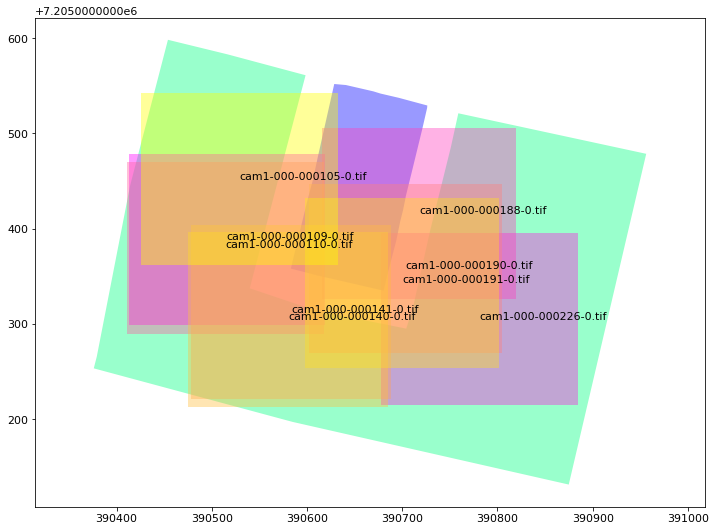

In [53]:
# Plot when done to get a sense of images and locations

# NOTE: need to re-subset polygs with dropflag
poly_gs = gpd.GeoSeries(data=pixel_dict['boundary_poly'], crs='EPSG:32736')
poly_gs = poly_gs.loc[pixel_dict['drop_flag']==0]

fig, ax = plt.subplots()
# for img in pixel_dict['pixels_xr'][1]:
#     img.plot(ax=ax, alpha=0.3)

ax.axis('equal')
# clipbox.plot(ax=ax, alpha=0.3)
shp.plot(ax=ax, cmap='winter', alpha=0.4)
poly_gs.plot(ax=ax, alpha=0.4, cmap='spring')

labels = [str(s).split('/')[-1] for s in np.array(pixel_dict['imgf'])[pixel_dict['drop_flag']==0]]

for cx, cy, t in zip(poly_gs.centroid.x.values, poly_gs.centroid.y.values, labels):
    ax.text(cx, cy, t)